# Sales Forecasting for Retail Decision-Making  
## A Business Intelligence Case Study Using Walmart Sales Data  

**Module:** Business Intelligence and Data Mining (UFCFMM)  
**Assessment:** Group Project Portfolio  
**Team Members:** [Add Names]  
**Dataset Source:** Kaggle – Walmart Sales Dataset  

---

## 1. Executive Summary

In [7]:
!pip install matplotlib seaborn
!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 111.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 186.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 2. Business Context & Problem Definition


In [2]:
The Business context

Walmart is a large-scale retail organisation that operates within a highly competitive and low-margin market where operational efficiency and demand responsiveness is key to lasting profitability. 
 Sales forecasting is a strategic asset that underpins inventory management, workforce allocation, supply chain coordination, promotional planning and financial forecasting.
An inaccurate financial forecast can cause substantial operational inefficiencies. An overwhelming amount of demands will lead to overstocking, an increased holding cost, markdown losses and waste products. 
    Also, undermining the forecast can lead to stockouts, lost revenue and loss of customer satisfaction. In short, even small forecasting errors can turn into a significant financial impact especialy when aggregated across department across department and regions.
The retail demand is influenced by multiple factors. Seasonal change (Holiday periods)
Unemployment inflation.

External costs (Fuel prices. The higher the cost of fuel, the less amount the customer will spend.)

the business problem
This project will address the following problem. How can historical weekly sales data across Walmart stores be analysed for firstly the forecast future sales with acceptable predictive accuracy? 
Secondly, identify the key structure and the economic factors that would influence the sales variability, therefore enabling data-driven operational planning

The problem is divided into two different sections.
Predictive dimensions (Generating the forward-looking sales forecast)
Diagnostic dimensions (Understand what drives sales variation)

By combining the forecasting with explanatory analysis, we move beyond technical modelling and towards actionable business intelligence,
aligning directly with the learning outcomes of investigating real-world applications of data mining in business contexts.

Local store Intelligence

A competent business intelligence system will be able to identify the demand drivers and will be able to produce relable forecast and provide a competitive advantage.

SyntaxError: invalid syntax (4242746293.py, line 1)

## 3. Dataset Description & Justification

Stage 3: Data mining and business insights 

Modeling Strategy Justification 

Problem type 

The objective of this project is to forecast the total weekly sales across all Walmart stores As the target variable, weekly sales, is continuous and numerical, this task will be formulated as a supervised prediction task 

The issue with a classification problem is that they predict the categorical outcomes. However the regression models estimate the continuous values. (Clifford 2023) talks about The benefit of an accurate regression modeling is that it is highly effective in retail sales forecasting. This enables my team to be able to generate reliable predictions that support the inventory planning, resource allocation, and strategic decision-making. 

Temporal Nature of the Data 

Temporal nature of data is information that is time related capturing changes or trends this benefits us because the Walmart dataset we used contains weekly time-indexed sales observations. Because of this temporal structure. 

Observations are not independent 
Past sales are likely correlated with future sales 
Chronological order must be preserved 

For us to prevent data leakage and ensure realistic forecasting performance, the dataset will be split chronologically rather than a random data selection. 

Model selection rationale. 

Model selection rational is the documented justification for picking a certain machine learning models over other module.To evaluate forecasting performance proffesonalytwo models wil be used. 

Linear regression (base model)

Simplicity and interpretability 
Ability to capture linear pattern trends 
Low risk of overfitting 
Strong baseline comparison 

By my team deciding to use baseline models, it  allows us to asses wether more complex techniques provide meaningful improvement 

Random Forest Regressor (non-linear models) 
 
A random forest regressor combines multiple decision trees to create a single model. We selected the random forest regressor because 

It captures nonlinear relationships 
It models interactions between features automatically 
It is robust to noise 
It performs well on structured tabular datasets. 

As there is a presence of seasonal effects on holiday spikes identified during the EDA a non linear ensemble method may better capture complex demand behavour 


Evaluation metrics 

The way we are going to be evaluating using two performance models. The first one is Mean Absolute Error (MAE). this module measures the average absolute deviation in weekly sales predictions. The second module is Root Mean Squared Error (RMSE) this model will peanilse the large errors. This is important when forecasting peak seasonal demand. These metrics provide complementary perspectives on the forecasting accuracy and business risk. 





Stage 3 references 

Clifford, D. (2023) Regression analysis: Use it to predict future sales and optimize your sales forecasts. Smart Sales Toolkit. Available at: https://medium.com/smart-sales-toolkit/regression-analysis-use-it-to-predict-future-sales-and-optimize-your-sales-forecasts-9f2a85ee2dba (Accessed: 25 February 2026).

## 4. Technical Setup & Data Loading

In [3]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Walmart.csv")

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## 5. Data Quality Assessment


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [4]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [5]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


### Data Quality Summary

The dataset contains 6,435 observations across 45 Walmart stores, with 8 variables describing weekly sales and related economic indicators.

No missing values were detected across any variables, indicating a complete dataset suitable for modelling without imputation.

Weekly sales range from approximately £209,986 to £3,818,686, with an average weekly sales value of approximately £1,046,965. This substantial variability highlights the operational importance of accurate demand forecasting in large retail environments.

All economic indicators (Temperature, Fuel Price, CPI, and Unemployment) appear numerically consistent and require no immediate cleaning. However, the Date variable was initially stored as a string and has been converted to datetime format to enable time series analysis.


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [7]:
df.isnull().sum()


Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [8]:
df.describe()


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


## 6. Exploratory Data Analysis (EDA)


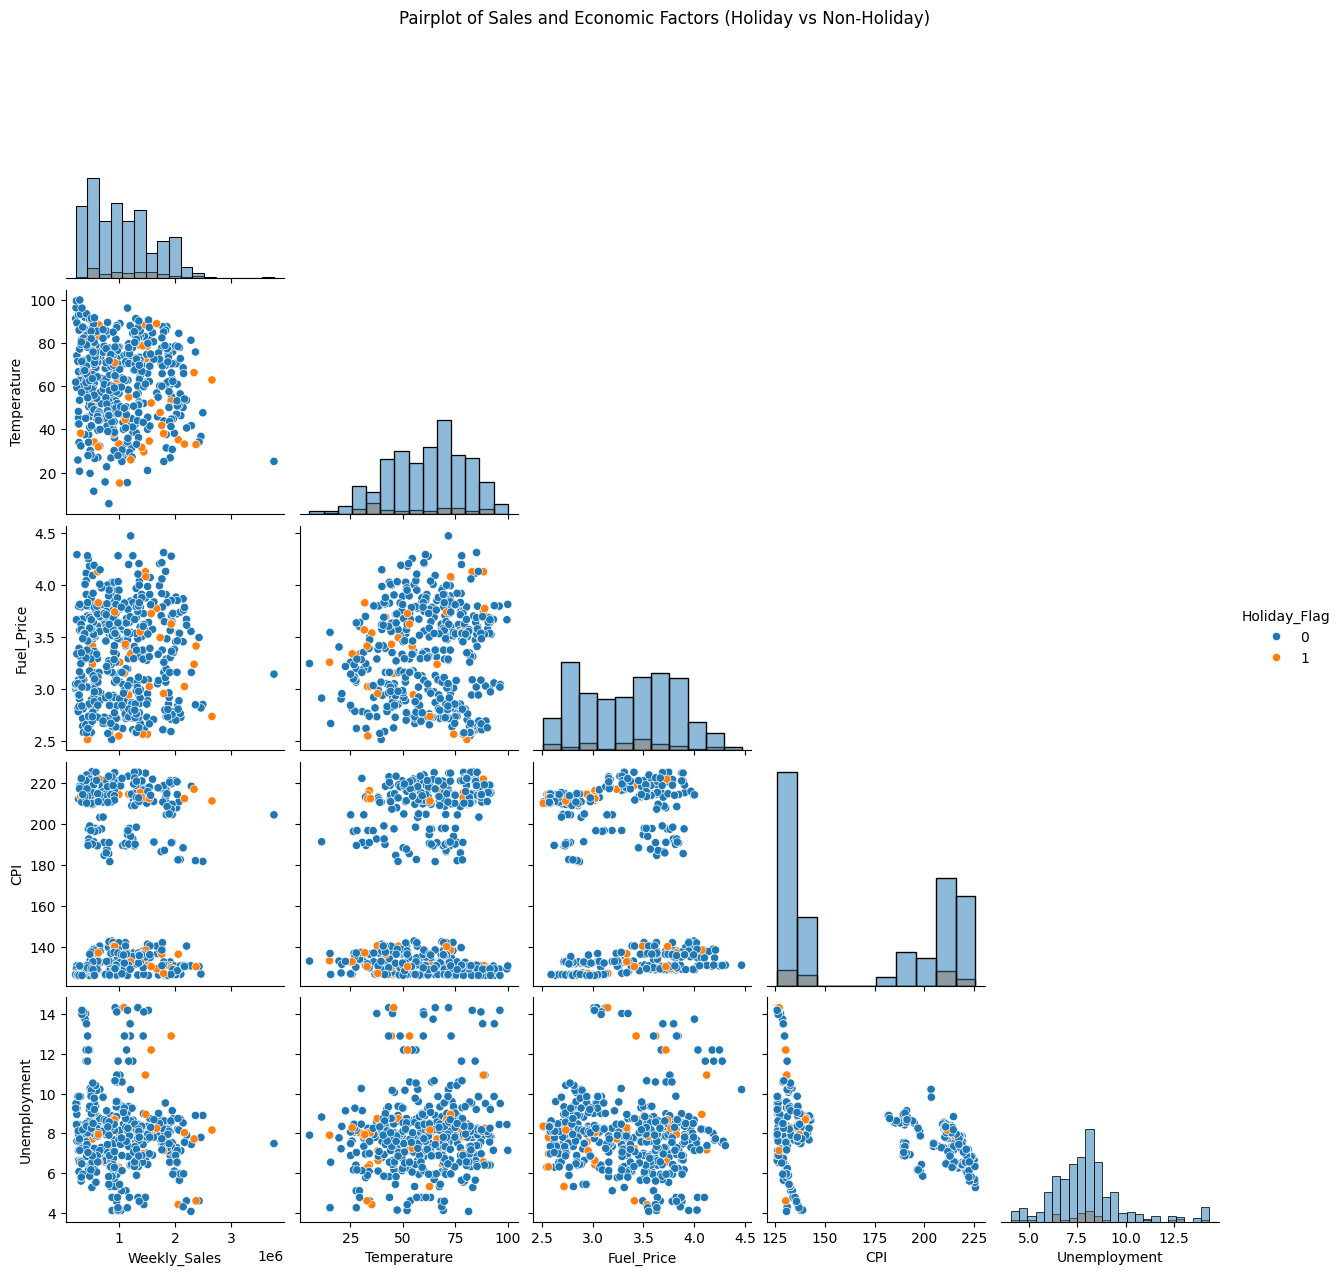

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Walmart.csv")

pairplot_df = df[[
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Holiday_Flag"
]]

pairplot_sample = pairplot_df.sample(500, random_state=42)

sns.pairplot(
    pairplot_sample,
    vars=["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment"],
    hue="Holiday_Flag",
    diag_kind="hist",
    corner=True
)

plt.suptitle("Pairplot of Sales and Economic Factors (Holiday vs Non-Holiday)", y=1.02)

plt.show()

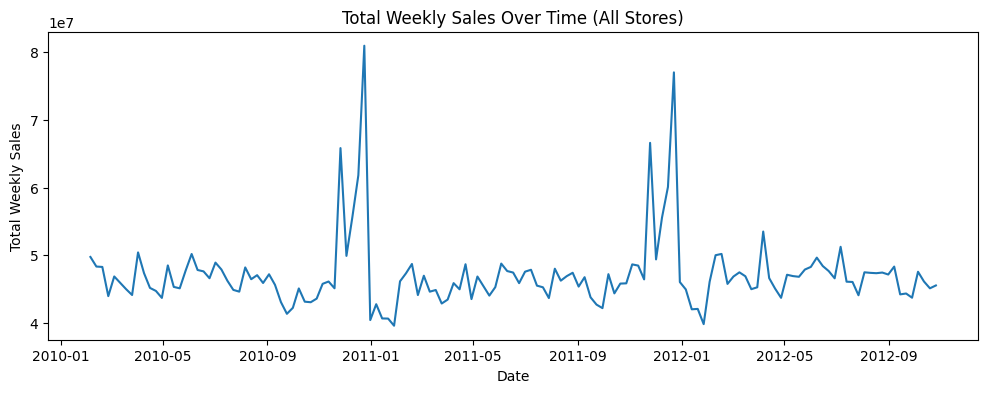

In [5]:
plt.figure(figsize=(12,4))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'])
plt.title("Total Weekly Sales Over Time (All Stores)")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.show()


### Time-Series Trend Insight

The aggregated weekly sales exhibit substantial volatility over time, with most weeks falling between approximately £40–50 million in total revenue.

Two pronounced spikes are visible in late 2010 and late 2011, likely corresponding to peak holiday shopping periods. These seasonal surges are followed by sharp declines, suggesting post-holiday demand contraction.

The presence of clear seasonal peaks indicates that holiday effects play a significant role in sales variation, reinforcing the need to incorporate temporal and seasonal features into forecasting models.


In [6]:
# Extract holiday flag per date (since it's consistent across stores)
holiday_info = df[['Date', 'Holiday_Flag']].drop_duplicates()

# Merge with weekly total
weekly_total = weekly_total.merge(holiday_info, on='Date')

weekly_total.head()


,Date,Weekly_Sales,Holiday_Flag
0,2010-02-05,49750740.50,0
1,2010-02-12,48336677.63,1
2,2010-02-19,48276993.78,0
3,2010-02-26,43968571.13,0
4,2010-03-05,46871470.30,0


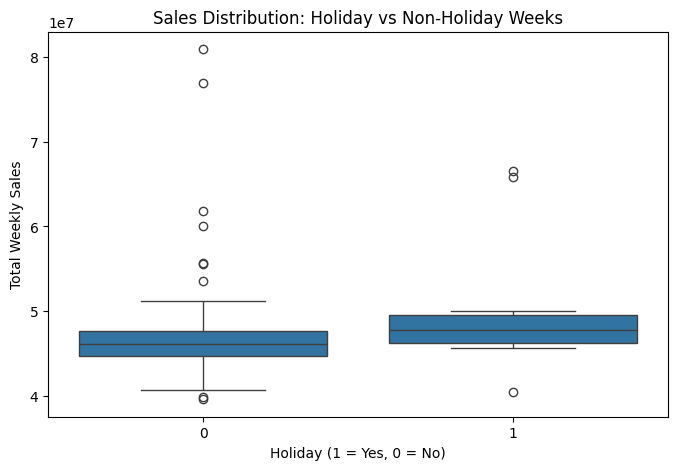

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=weekly_total)

plt.title("Sales Distribution: Holiday vs Non-Holiday Weeks")
plt.xlabel("Holiday (1 = Yes, 0 = No)")
plt.ylabel("Total Weekly Sales")
plt.show()


### Holiday Effect Analysis

Holiday weeks exhibit a slightly higher median sales level compared to non-holiday weeks. However, the difference is not substantial across the majority of observations.

While certain holiday weeks generate extreme sales spikes (as shown by high-value outliers), most holiday weeks display sales levels similar to regular weeks. This suggests that although holiday effects contribute to demand increases, broader seasonal patterns (particularly in late-year months) likely play a more significant role in driving peak sales.

This finding indicates that relying solely on the Holiday_Flag variable may be insufficient for capturing full seasonal dynamics in forecasting models.


## 7. Feature Engineering & Preprocessing


In [3]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[us]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(2)
memory usage: 402.3 KB


In [4]:
# Aggregate total weekly sales across all stores
weekly_total = (
    df.groupby('Date', as_index=False)['Weekly_Sales']
      .sum()
      .sort_values('Date')
)

weekly_total.head()


,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


## 8. Baseline forecast models 

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [13]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [15]:
total_sales = df.groupby("Date")["Weekly_Sales"].sum().reset_index()
total_sales = total_sales.sort_values("Date")
total_sales.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [17]:
total_sales["Lag_1"] = total_sales["Weekly_Sales"].shift(1)
total_sales["Lag_4"] = total_sales["Weekly_Sales"].shift(4)
total_sales["Lag_12"] = total_sales["Weekly_Sales"].shift(12)

In [18]:
total_sales = total_sales.dropna()

In [19]:
total_sales.head()

,Date,Weekly_Sales,Lag_1,Lag_4,Lag_12
12,2010-04-30,43705126.71,44734452.56,50423831.26,49750740.50
13,2010-05-07,48503243.52,43705126.71,47365290.44,48336677.63
14,2010-05-14,45330080.20,48503243.52,45183667.08,48276993.78
15,2010-05-21,45120108.06,45330080.20,44734452.56,43968571.13
16,2010-05-28,47757502.56,45120108.06,43705126.71,46871470.30


In [20]:
X = total_sales[["Lag_1", "Lag_4", "Lag_12"]]
y = total_sales["Weekly_Sales"]

In [21]:
train_size = int(len(total_sales) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [22]:
print("Training size:", len(X_train))
print("Test size:", len(X_test))

Training size: 104
Test size: 27


I also created a chronological train test split. This was applied to preserve temporal ordering and prevent data leakage. Random splitting was avoided because future sales data can influence historical model training in the forecasting context.

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [24]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
y_pred_lr = model_lr.predict(X_test)

In [26]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression MAE: 1244363.8914730276
Linear Regression RMSE: 1644287.2595822518


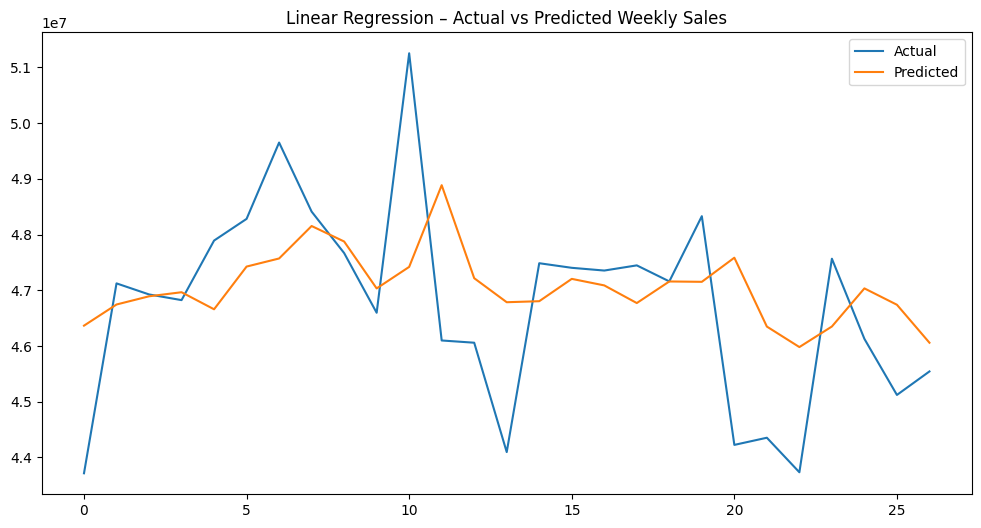

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_lr, label="Predicted")
plt.legend()
plt.title("Linear Regression – Actual vs Predicted Weekly Sales")
plt.show()

This linear regression model provides the foundation forecast using lag features. While the linear regression model captures the general trend behavour deviations are seen during the high-volatility periods, especially around seasonal peaks. 

## 9 Forecasting models

In [2]:
from sklearn.ensemble import RandomForestRegressor

In [8]:
import pandas as pd

df = pd.read_csv("Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [9]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [10]:
total_sales = df.groupby("Date")["Weekly_Sales"].sum().reset_index()

total_sales = total_sales.sort_values("Date")

total_sales.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [11]:
total_sales["Lag_1"] = total_sales["Weekly_Sales"].shift(1)
total_sales["Lag_4"] = total_sales["Weekly_Sales"].shift(4)
total_sales["Lag_12"] = total_sales["Weekly_Sales"].shift(12)

total_sales = total_sales.dropna()

In [12]:
X = total_sales[["Lag_1", "Lag_4", "Lag_12"]]
y = total_sales["Weekly_Sales"]

In [13]:
train_size = int(len(total_sales) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [18]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("RF MAE:", mae_rf)
print("RF RMSE:", rmse_rf)

RF MAE: 1687685.604107401
RF RMSE: 2137621.4440077315


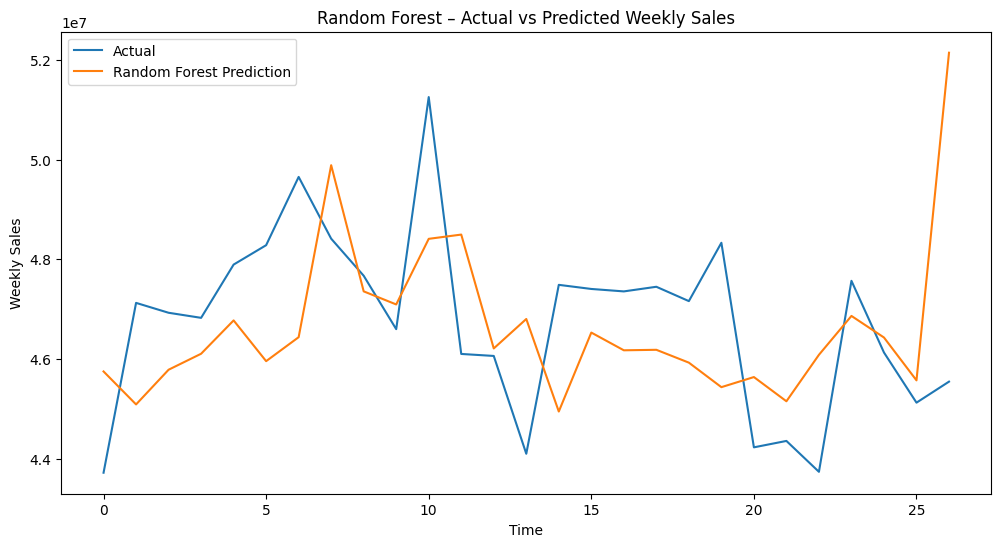

In [28]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_rf, label="Random Forest Prediction")
plt.legend()
plt.title("Random Forest – Actual vs Predicted Weekly Sales")
plt.xlabel("Time")
plt.ylabel("Weekly Sales")
plt.show()

## 10 Model Evaluation (Technical and business) 

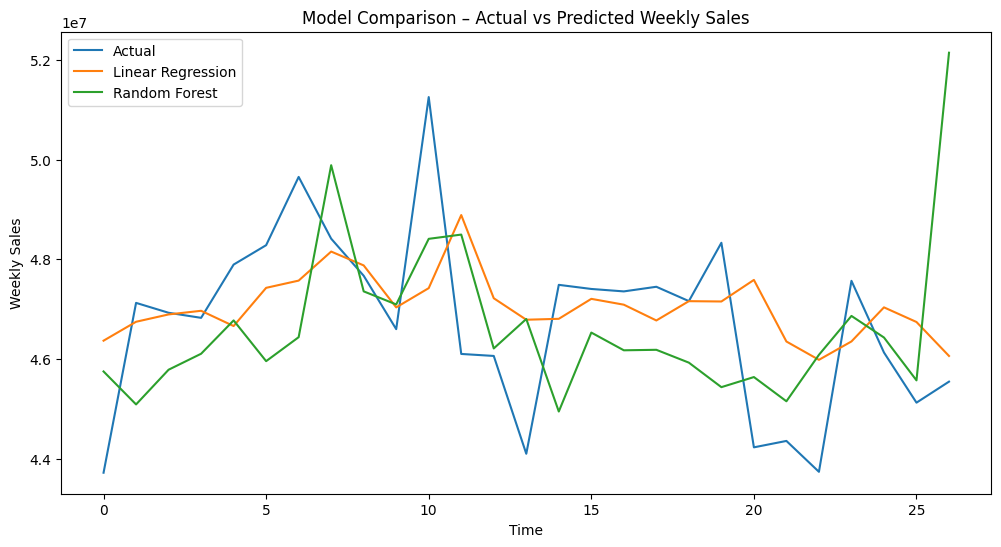

In [27]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_lr, label="Linear Regression")
plt.plot(y_pred_rf, label="Random Forest")
plt.legend()
plt.title("Model Comparison – Actual vs Predicted Weekly Sales")
plt.xlabel("Time")
plt.ylabel("Weekly Sales")
plt.show()

This comparison shows how closely each model's predictions follow the actual weekly sales for Walmart. The random forest models partialy tracks flucuation more effectivily espaccially for the low dips, than the linear regression model. This suggests that it captures more complex patterns in the sales data 

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("LR MAE:", mae_lr)
print("LR RMSE:", rmse_lr)

LR MAE: 1244363.8914730276
LR RMSE: 1644287.2595822518


In [22]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf]
})

results

,Model,MAE,RMSE
0,Linear Regression,1.244364e+06,1.644287e+06
1,Random Forest,1.687686e+06,2.137621e+06


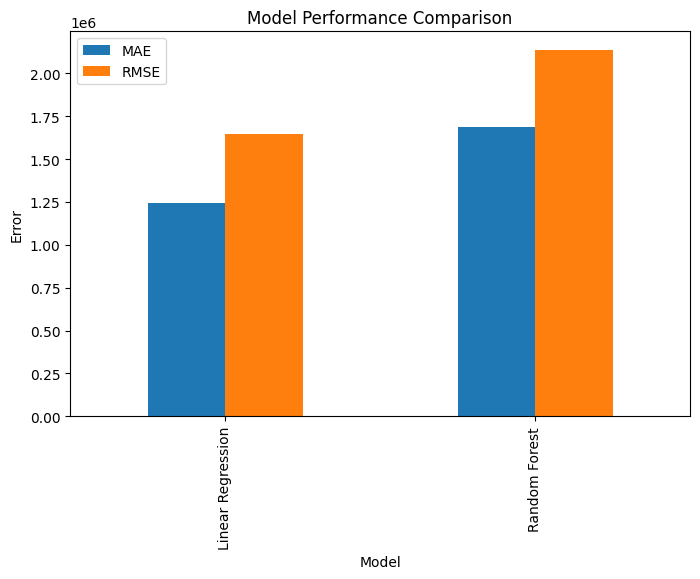

In [23]:
results.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.show()

Interpret the model Results 

I have made two forecasting models that were used to evaluate predictive performance. i used linear regression and random forest. linear regression was used as a baseline model due the simplicity and interpretability. However, the Random Forest model was added to capture the possible nonlinear relationships in the sales data 

Results 

The results show that the random Forrest model achived Mean Absolute Error (MAE) of around £1.69 million and a Root Mean Squared Error (RMSE) of around £2.14 million per week. These metrics show the average devation between the predicted and actual weekly sales. 

Comparing 

i compared that both these models allows me to asses wether a more complex model improves the predictive accuracy. in retail forecasting scenarios, ensemble models such as Random Performance models as random forrest perform better because they can capture the more complex demand patterns and seasonal fluctuations that the simple linear models can't represent. 

Business interpretation 

From the business intelligence perspective, forecasting accuracy has direct operational implications. forecast errors can lead to either stock shortages or overstocking across 45 different Walmart stores. Underforecasting can result in lost sales and reduced customer satisfaction. Overstocking can also increase the storage cost and inventory waste. 

Therefor a forecasting model that can reduce prediction error can improve demand planning, inventory management and resource allocation. Even small improvements in forecasting accuracy can produce massive financial benefits when applied across a supermarket giant like Walmart. 

In [23]:
from sklearn.model_selection import train_test_split

X = df.drop("Weekly_Sales", axis=1)
y = df["Weekly_Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

In [17]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Date"].dt.day

In [18]:
df = df.drop("Date", axis=1)

In [20]:
X = df.drop("Weekly_Sales", axis=1)
y = df["Weekly_Sales"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [25]:
y_pred_rf = rf_model.predict(X_test)

In [26]:
# Calculate residuals (prediction errors)
residuals_rf = y_test - y_pred_rf

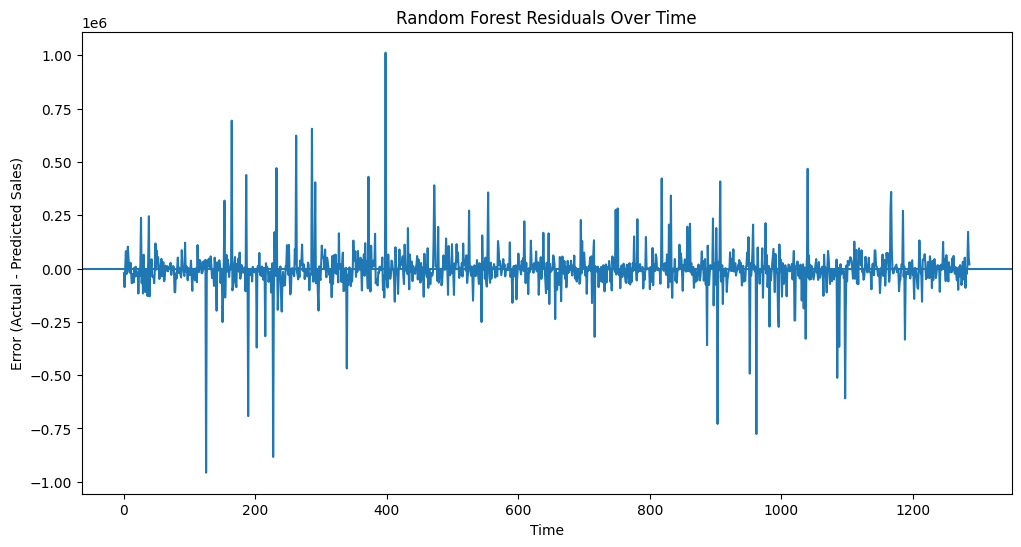

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(residuals_rf.values)

plt.axhline(0)

plt.title("Random Forest Residuals Over Time")
plt.xlabel("Time")
plt.ylabel("Error (Actual - Predicted Sales)")

plt.show()

The residual plot illustrates the prediction errors of the Random Forest model, calculated as the difference between actual and predicted weekly sales. Ideally, residuals should be randomly distributed around zero, indicating that the model does not consistently overestimate or underestimate values. In this case, most residuals are clustered near the zero line, suggesting that the model generally produces accurate predictions for typical sales levels. The lack of a visible trend or pattern indicates that the model does not suffer from systematic bias. However, several large positive and negative spikes are present, representing weeks where prediction errors are significantly higher. These deviations likely correspond to unusual demand patterns or external factors not fully captured by the model. Overall, the residual distribution indicates that the model performs reliably for normal sales behaviour but is less accurate during periods of extreme variation.

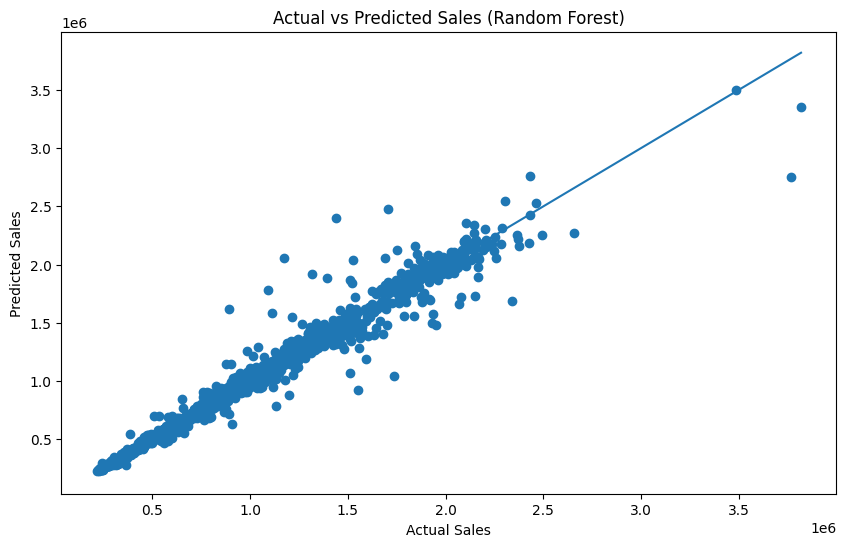

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_rf)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

plt.title("Actual vs Predicted Sales (Random Forest)")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.show()

 The Actual vs Predicted plot shows the relationship between real sales values and the values forecast by the Random Forest model. Most points are positioned close to the diagonal reference line, indicating that the model predicts sales reasonably accurately. However, some points deviate from the line, suggesting reduced accuracy for certain observations, particularly where sales fluctuate more sharply.

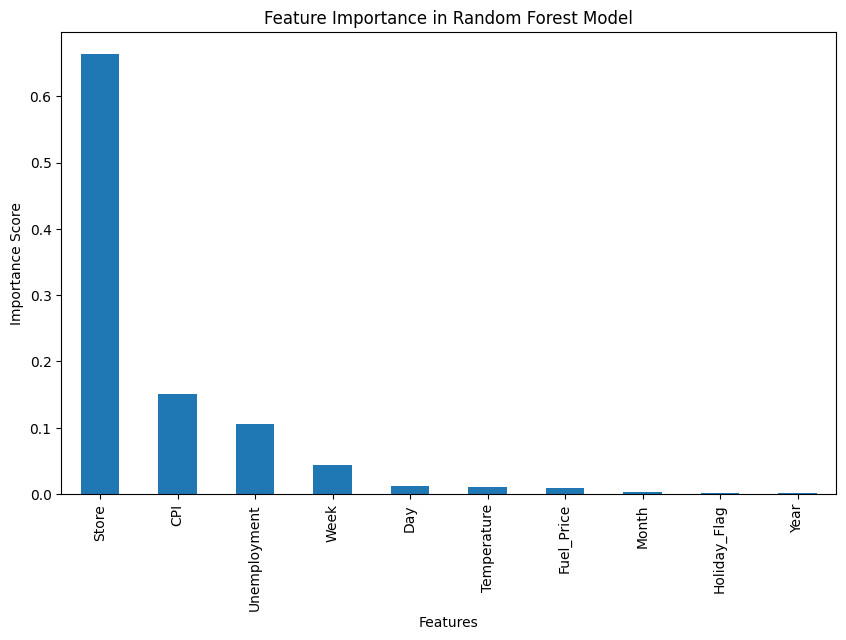

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.plot(kind="bar")

plt.title("Feature Importance in Random Forest Model")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

 The feature importance plot indicates which variables contributed most to the Random Forest model’s predictions. Features with higher importance scores had a stronger influence on forecasted sales, suggesting that these variables are more useful for explaining changes in weekly sales performance.

Overall Model Evaluation

The evaluation results suggest that the Random Forest model provides a reliable approach for forecasting weekly sales within the dataset. The Actual vs Predicted plot demonstrates a strong alignment between predicted and observed sales values, indicating that the model successfully captures the general patterns present in the data. Residual analysis further supports this finding, as most prediction errors are distributed around zero without any clear systematic pattern, suggesting that the model does not consistently overestimate or underestimate sales. While several larger residual spikes are visible, these likely correspond to periods of unusual demand or external influences not fully represented by the available features. Overall, the model performs well in capturing typical sales behaviour and provides a robust foundation for sales forecasting, although its accuracy may decrease during periods of extreme variability.

## 11. Strategic Recommendations


## 12. Ethical, Privacy & Security Evaluation


## 13. Conclusion


## 14. References
